<a href="https://colab.research.google.com/github/Praise-Oluwasikemi/TS-Academy-Group-4-IBM-HR-Analytics-Attrition/blob/main/TS_ACADAEMY_GROUP_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Submission Summary

| Field | Value |
|---|---|
| Group number | 04 |
| Your full name | *** YOUR NAME HERE *** |
| Dataset | IBM HR Analytics Attrition |
| Depth track | Classification Depth |
| Team members | DAVID WEALTH, MICHAEL SAMPSON,OKOGBO JOSEPH, VITOR ODURONBI, HELEN EMIEWO, POPOOLA TEMIDAYO, OGUNRIONOLA CHRISTANAH, BETHEL, DORCAS YUSUF, PRAISE ADETAYO |
| Final model | *** filled in after Part 5 *** |
| Stratified dummy F1 / ROC AUC | *** filled in after Part 4 *** |
| Final model F1 / ROC AUC | *** filled in after Part 5 *** |
| Leakage columns dropped | None found |
| Full run time on Colab | *** filled in at the end *** |

# What this project is about

A company has records for 1,470 of its employees. For each person we know things
like their age, salary, job, how far they live from the office, how long they have
been there, and how they rated their satisfaction at work. We also know one more
thing about each of them: whether they resigned or stayed (ATTRITION).

The company wants two things from this data. First, an honest picture of what
natural types of employee exist here. Second, something that can spot the people
likely to resign, before they do.

That is what this notebook does, working through it in seven parts. Our explanation as a group is written in a way that
someone who has never seen code before can read it from top to bottom and
follow what happened and why.

## Part 1. Data Foundation

Before building anything, understand the data.

### 1.0 Getting the tools ready

This first block loads all the software tools the notebook will use. Nothing
interesting happens here, but it has to run first or nothing else works.

In [ ]:
# Install the one extra package Colab does not come with.
# kagglehub is what lets this notebook download the dataset by itself.
!pip install -q kagglehub

# This start a stopwatch so as to report at the end how long the whole notebook took to run.
import time
RUN_START = time.time()

# Tools for handling files and databases
import os, sqlite3, warnings

# Tools for working with tables of data and doing maths on them
import numpy as np
import pandas as pd

# Tools for drawing charts
import matplotlib.pyplot as plt
import seaborn as sns

# The tool that downloads the dataset from Kaggle
import kagglehub

# Machine learning tools
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Hide warning messages that clutter the output but do not affect results
warnings.filterwarnings('ignore')

# Fix the random seed so that all group members re-running this notebook gets the same number
#Without this, results shift slightly every run.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Chart styling and an instruction to show all columns when printing tables
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 100)

print('All libraries loaded. Ready to start.')

All libraries loaded. Ready to start.


### 1.1 Getting the data and putting it into a database

The data is downloaded from Kaggle by the notebook itself rather than uploaded manaually. This matters because it means anyone can open this notebook on a fresh
computer and it will fetch everything it needs on its own.

Next up, copying the data into a small database. A database lets us ask questions of the
data using SQL, which is the standard language for asking questions of stored
information.

In [ ]:
# Download the dataset straight from Kaggle.
path = kagglehub.dataset_download('pavansubhasht/ibm-hr-analytics-attrition-dataset')

# Find the CSV file inside the downloaded folder and read it into a table
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df_raw = pd.read_csv(os.path.join(path, csv_file))

# Copy that table into a small database file to ask questions using SQL
conn = sqlite3.connect('hr.db')
df_raw.to_sql('employees', conn, if_exists='replace', index=False)

print('File downloaded:', csv_file)
print('The data has', df_raw.shape[0], 'employees and', df_raw.shape[1], 'columns.')
print('Rows now stored in the database:',
      pd.read_sql('SELECT COUNT(*) AS n FROM employees', conn).iloc[0, 0])

# show the first five employees so we can see what the data looks like
df_raw.head()

100%|██████████| 50.1k/50.1k [00:00<00:00, 32.4MB/s]

Extracting files...


File downloaded: WA_Fn-UseC_-HR-Employee-Attrition.csv
The data has 1470 employees and 35 columns.
Rows now stored in the database: 1470


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


### 1.2 Three questions for the data

I imagined myself sitting with the HR manager of this company. She is worried about
staff leaving. She has a limited budget to do something about it and needs to know
where to spend it. These are the three things I would most want to tell her.

#### Question 1: Where are we losing people?

I asked this in two steps. First by department, because there are only three of
them, so each one has plenty of people in it and the percentages can be trusted.
Then I looked inside the biggest department at the individual job roles, because an
average across a whole department can hide a problem sitting in one particular
role.

In [ ]:
# Count how many people work in each department, how many of them left,
# and turn that into a percentage.
q1a = """
SELECT Department,
       COUNT(*) AS total_staff,
       SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS quit_count,
       ROUND(100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 1) AS quit_pct
FROM employees
GROUP BY Department
ORDER BY quit_pct DESC
"""
pd.read_sql(q1a, conn)

,Department,total_staff,quit_count,quit_pct
0,Sales,446,92,20.6
1,Human Resources,63,12,19.0
2,Research & Development,961,133,13.8


In [ ]:
# Now the same question, but looking only inside Research & Development,
# broken down by the individual job roles within it.
q1b = """
SELECT JobRole,
       COUNT(*) AS total_staff,
       SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS quit_count,
       ROUND(100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 1) AS quit_pct
FROM employees
WHERE Department = 'Research & Development'
GROUP BY JobRole
ORDER BY quit_pct DESC
"""
pd.read_sql(q1b, conn)

,JobRole,total_staff,quit_count,quit_pct
0,Laboratory Technician,259,62,23.9
1,Research Scientist,292,47,16.1
2,Manufacturing Director,145,10,6.9
3,Healthcare Representative,131,9,6.9
4,Manager,54,3,5.6
5,Research Director,80,2,2.5


**What I found**

Sales is the worst department, losing 20.6% of its staff. Research and Development
looks much healthier at 13.8%, and Human Resources sits at 19% but only has 63
people in it, so that figure moves a lot if just two or three more people leave.
Sales, with 446 people, is the number I would rely on.

Then the second table changes the picture. Inside Research and Development, which
looked like the calm department, Laboratory Technicians are leaving at 23.9%. That
is worse than Sales. There are 259 of them, so this is not a small-sample fluke.
The department average of 13.8% hid it completely.

So the honest answer to the HR manager is: yes, Sales is your problem, and you also
have a problem with Laboratory Technicians that your departmental reports are not
showing you.

What this data cannot tell me is why. There is no column recording anyone's
reasons. It might be workload, staffing levels, the number of samples each
technician handles, or something nobody has thought of. That would have to be found
out by asking them directly.

#### Question 2: Do people who work overtime leave more?

In [ ]:
# Compare people who work overtime against people who do not,
# and see what share of each group left.
q2 = """
SELECT OverTime,
       COUNT(*) AS total_staff,
       SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS quit_count,
       ROUND(100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 1) AS quit_pct
FROM employees
GROUP BY OverTime
ORDER BY quit_pct DESC
"""
pd.read_sql(q2, conn)

,OverTime,total_staff,quit_count,quit_pct
0,Yes,416,127,30.5
1,No,1054,110,10.4


**What I found**

People who work overtime leave at 30.5%. People who do not leave at 10.4%. That is
three times the rate, and it is the biggest gap I found anywhere in this dataset.

If overtime is driving people out, then the sensible response is to hire more staff
so the work spreads further and fewer people get pushed into overtime in the first
place. That is something a budget can actually fix.

One thing I want to be careful about. This shows that overtime and resigning happen
to the same people. It does not prove that overtime is what causes them to resign.
It could be that overtime lands hardest on teams that were already under strain for
other reasons, and the strain is the real cause. So I would treat extra hiring as
something worth trying and measuring, not as a guaranteed cure.

#### Question 3: Do the people who leave earn less than the people who stay?

In [ ]:
# For each department, compare the average salary of the people who stayed
# against the average salary of the people who left.
q3 = """
SELECT Department,
       Attrition,
       COUNT(*) AS staff,
       ROUND(AVG(MonthlyIncome), 0) AS avg_monthly_income
FROM employees
GROUP BY Department, Attrition
ORDER BY Department, Attrition
"""
pd.read_sql(q3, conn)

,Department,Attrition,staff,avg_monthly_income
0,Human Resources,No,51,7346.0
1,Human Resources,Yes,12,3716.0
2,Research & Development,No,828,6630.0
3,Research & Development,Yes,133,4108.0
4,Sales,No,354,7232.0
5,Sales,Yes,92,5908.0


**What I found**

In Human Resources and in Research and Development, the people who left were
earning roughly half what the people who stayed were earning. In Sales the gap is
much smaller.

A full salary review across the company is probably too expensive. A more realistic
option is to target bonuses or other incentives at the lowest-paid staff
specifically. That costs far less than raising everybody's base pay, and it reaches
the group most at risk of walking.

There is a complication I cannot resolve at this stage. The lowest earners in this
company are also mostly the youngest and newest staff, who tend to move jobs more
often anyway, regardless of what they are paid. So I cannot yet tell whether people
are leaving because the pay is low or because they are early in their careers. I
come back to this in Part 2 and build something specifically to separate the two.

### 1.3 Looking at the data as a whole

In [ ]:
# The basic facts about the dataset before I change anything.

print('Number of employees and number of columns:', df_raw.shape)
print()

print('What kind of information each column holds:')
print(df_raw.dtypes.value_counts())
print()

# Check whether any information is missing anywhere in the table
print('Total number of empty cells in the whole dataset:', df_raw.isnull().sum().sum())
print()

# Count how many people left and how many stayed
print('How many people left versus stayed:')
print(df_raw['Attrition'].value_counts())
print()
print('The same thing as a proportion:')
print(df_raw['Attrition'].value_counts(normalize=True).round(4))

Number of employees and number of columns: (1470, 35)

What kind of information each column holds:
int64     26
object     9
Name: count, dtype: int64

Total number of empty cells in the whole dataset: 0

How many people left versus stayed:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

The same thing as a proportion:
Attrition
No     0.8388
Yes    0.1612
Name: proportion, dtype: float64


**What the basic numbers tell me**

There are 1,470 employees and 35 columns of information about them, with no missing
values anywhere. That is unusual and it makes life easier.

237 people left and 1,233 stayed. So the people I am trying to predict are only
16.12% of the data, roughly one in six.

That single number shapes everything that follows, and it is worth being clear
about why. Suppose I built something that simply said "nobody will ever resign" for
every single employee, without looking at anything. It would be right 83.88% of the
time, because most people really do stay. It would also be completely useless,
because it would never once flag somebody who was about to leave, which was the
whole point.

So I cannot judge this work by how often it is right overall. The question that
matters is: out of the 237 people who actually left, how many did I catch? That
idea runs through the rest of the notebook, and Part 5 deals with it head on.

The row count matters too. 1,470 is below the 2,000 mark, so in Part 4 I test the
models using cross-validation rather than a single split of the data. I explain
what that means when I get there.

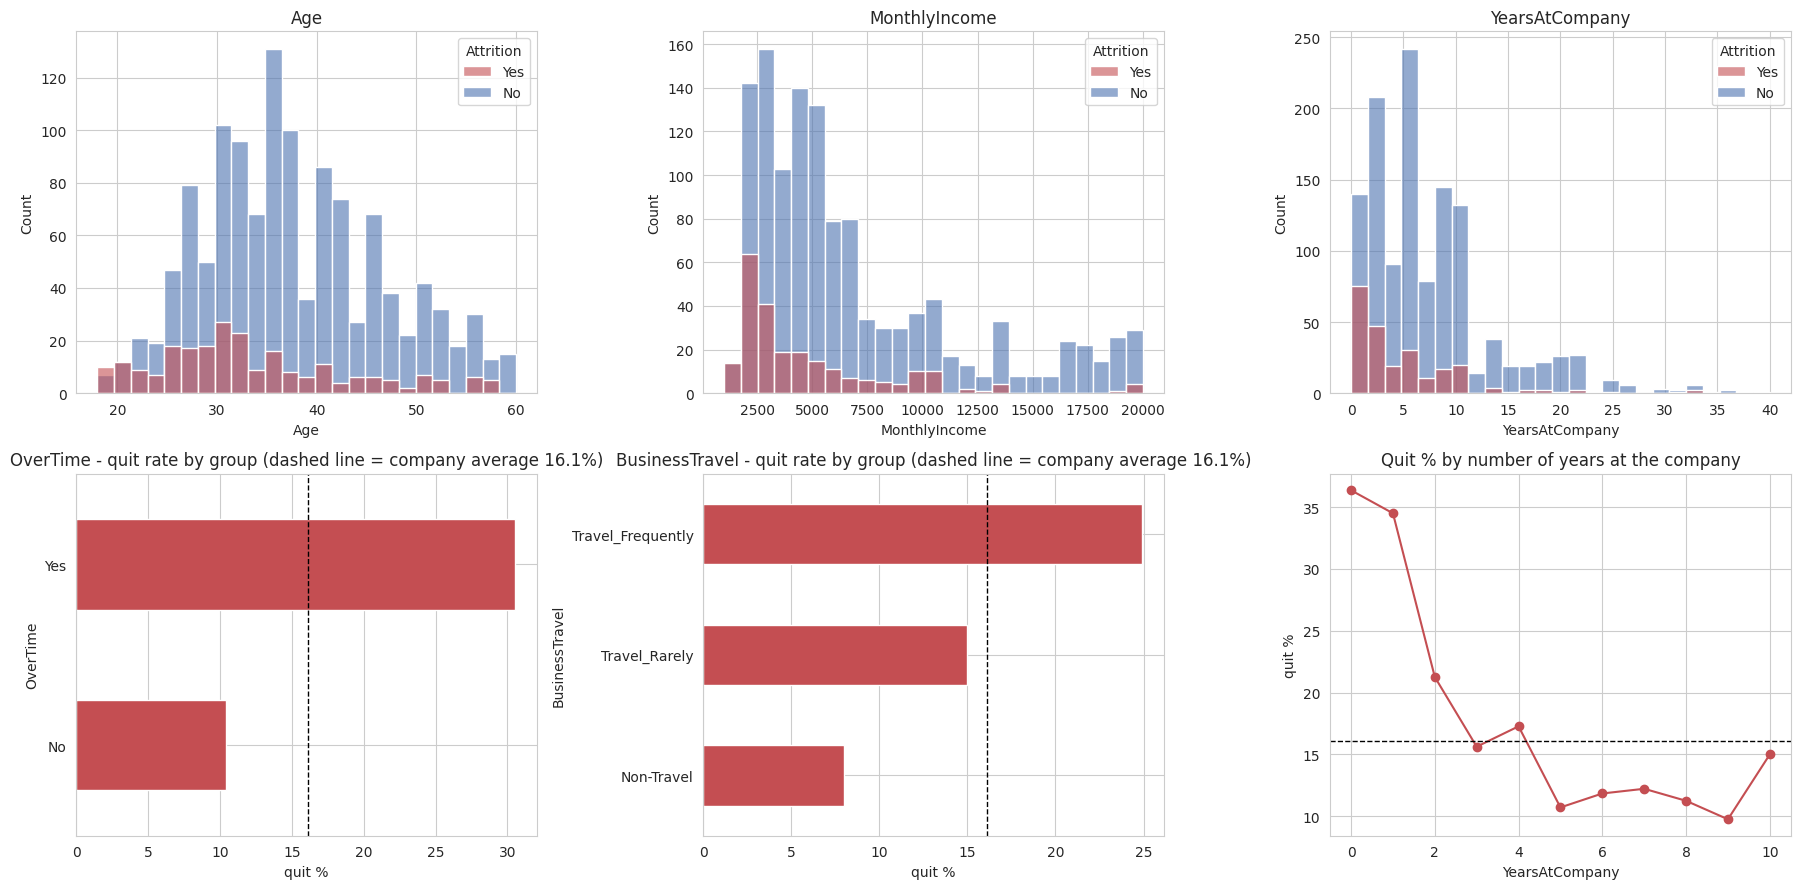

In [ ]:
# Five charts. Red means the employee left, blue means they stayed.

fig, ax = plt.subplots(2, 3, figsize=(18, 9))
colours = {'No': '#4C72B0', 'Yes': '#C44E52'}

# The overall quit rate, used as a reference line on the bottom charts
overall = 100 * (df_raw['Attrition'] == 'Yes').mean()

# Top row: three columns that are ordinary numbers, showing how leavers and
# stayers are spread across each one.
for i, col in enumerate(['Age', 'MonthlyIncome', 'YearsAtCompany']):
    sns.histplot(data=df_raw, x=col, hue='Attrition', bins=25,
                 palette=colours, alpha=0.6, ax=ax[0, i])
    ax[0, i].set_title(col)

# Bottom left two: quit rate for each category, with a dashed line showing the
# company average so it is obvious which groups are worse than normal.
for i, col in enumerate(['OverTime', 'BusinessTravel']):
    rates = df_raw.groupby(col)['Attrition'].apply(lambda s: 100 * (s == 'Yes').mean()).sort_values()
    rates.plot(kind='barh', color='#C44E52', ax=ax[1, i])
    ax[1, i].axvline(overall, ls='--', c='k', lw=1)
    ax[1, i].set_title(f'{col} - quit rate by group (dashed line = company average {overall:.1f}%)')
    ax[1, i].set_xlabel('quit %')

# Bottom right: how the quit rate changes with each extra year at the company.
tenure = df_raw.groupby('YearsAtCompany')['Attrition'].apply(lambda s: 100 * (s == 'Yes').mean())
tenure[tenure.index <= 10].plot(marker='o', color='#C44E52', ax=ax[1, 2])
ax[1, 2].axhline(overall, ls='--', c='k', lw=1)
ax[1, 2].set_title('Quit % by number of years at the company')
ax[1, 2].set_ylabel('quit %')

plt.tight_layout()
plt.show()

**What the charts show**

In the top three charts, red is people who left and blue is people who stayed. The
red is bunched towards the left in all three. The people leaving are younger, paid
less, and have been at the company for less time.

Notice also that the red is much smaller than the blue everywhere. That is the one
in six problem showing up visually.

The two bar charts show quit rates against the company average of 16.1%, drawn as a
dashed line. Overtime and frequent travel both sit well past it. People who travel
frequently leave at 24.9%, against 8% for people who never travel.

The clearest pattern of all is the last chart. Nearly 35% of people leave within
their first year. That falls to 21% in the second year and down to 8% for people
who have been there more than ten years. Get somebody past their first two years
and they tend to stay a long time.

Putting this together, age, salary and length of service are not three separate
findings. They describe one group of people: young, low paid, recently hired. That
overlap is exactly why the salary question could not be answered on its own, and it
is what I build for in the next part.

### 1.4 Cleaning the data

Every change below has a reason written next to it. I have not filled in or removed
anything just because it is the usual thing to do.

In [ ]:
# Working on a copy so the original downloaded data stays untouched.
df = df_raw.copy()

# --- Step 1: check for columns that hold no useful information ----------------
# A column where everybody has the same value cannot explain why some people
# left and others did not.
print('Checking four suspicious columns:')
for col in ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']:
    print('  %-16s number of different values: %5d' % (col, df[col].nunique()))

df = df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'])

# --- Step 2: check for missing information ------------------------------------
print()
print('Number of columns with any missing values:', (df.isnull().sum() > 0).sum())
print('Nothing is missing, so nothing needs to be filled in or removed.')

# --- Step 3: check for columns that give away the answer -----------------------
# looked through all 35 original columns for anything that would only be known
# after somebody had already resigned, such as a leaving date or an exit
# interview score. There is nothing like that in this dataset.

# --- Step 4: turn the answer column into numbers -------------------------------
# Models cannot read the words "Yes" and "No", so 1 means the person left
# and 0 means they stayed.
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print()
print('Columns remaining after cleaning:', df.shape[1])
print('Share of employees who left:', round(df['Attrition'].mean(), 4))

Checking four suspicious columns:
  EmployeeCount    number of different values:     1
  StandardHours    number of different values:     1
  Over18           number of different values:     1
  EmployeeNumber   number of different values:  1470

Number of columns with any missing values: 0
Nothing is missing, so nothing needs to be filled in or removed.

Columns remaining after cleaning: 31
Share of employees who left: 0.1612


**Why these changes?**

**Rremoved four columns.** EmployeeCount says 1 for every single person.
StandardHours says 80 for every single person. Over18 says Y for every single
person. A column where everybody is identical cannot possibly explain why some
people left and others did not, so all three are useless.

EmployeeNumber is the opposite problem. It has 1,470 different values because it is
just a staff ID. Some models would use it to memorise individual employees rather
than learn a real pattern, a bit like a student memorising the answer sheet instead
of learning the subject. It looks perfect in practice and fails completely on
anybody new.

**No rows removed and no filling in any values.** There is nothing
missing after checking the data.

**Checked for columns that give away the answer and found none.** The thing to
look for is a column that would only exist after somebody had already resigned, for
example a leaving date or an exit interview score. If such a column were left in, a
model would look brilliant while having learned nothing, because it would simply be
reading the answer. All 35 original columns here describe the employee while they
were still working, so there is nothing to remove. This is worth stating plainly
because some of the other datasets in this capstone do contain columns like that.

**Turned the answer(target) column into numbers**, where 1 means the person left, because
the models in Part 4 cannot work with the words Yes and No.

## Part 2. Feature Engineering and Encoding

In this part
three new columns are built that were not in the original file, to capture things the existing
columns only hint at.

### 2.1 Three new columns